In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings("ignore")

# Load and Understanding Dataset

In [40]:
# Loading Dataset
df = pd.read_csv("Healthcare_data.csv")

In [41]:
# Display basic information about the dataset
print("Dataset Information:")
print(df.info())

Dataset Information:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   PatientID          100 non-null    int64
 1   Gender             100 non-null    str  
 2   Age                100 non-null    int64
 3   Diagnosis          100 non-null    str  
 4   AppointmentDate    100 non-null    str  
 5   MissedAppointment  100 non-null    int64
dtypes: int64(3), str(3)
memory usage: 4.8 KB
None


In [42]:
print("First Few Rows of Data:")
print(df.head())

First Few Rows of Data:
   PatientID  Gender  Age      Diagnosis AppointmentDate  MissedAppointment
0          1    Male   70         Asthma      2023-04-18                  1
1          2  Female   43         Asthma      2023-05-07                  0
2          3  Female   73  Heart Disease      2023-11-12                  0
3          4  Female   49         Asthma      2023-10-15                  0
4          5    Male   65  Heart Disease      2023-03-05                  1


In [43]:
print("Descriptive Statistics:")
print(df.describe())

Descriptive Statistics:
        PatientID         Age  MissedAppointment
count  100.000000  100.000000         100.000000
mean    50.500000   52.370000           0.170000
std     29.011492   17.481682           0.377525
min      1.000000   18.000000           0.000000
25%     25.750000   40.000000           0.000000
50%     50.500000   52.000000           0.000000
75%     75.250000   67.000000           0.000000
max    100.000000   79.000000           1.000000


In [44]:
# Check for missing values
print("Missing Values:")
print(df.isnull().sum())

Missing Values:
PatientID            0
Gender               0
Age                  0
Diagnosis            0
AppointmentDate      0
MissedAppointment    0
dtype: int64


In [45]:
# Display unique values in categorical columns

categorical_columns = df.select_dtypes(include=["object"]).columns
for col in categorical_columns:
    print(f"\nUnique values in {col}:")
    print(df[col].value_counts())


Unique values in Gender:
Gender
Female    52
Male      48
Name: count, dtype: int64

Unique values in Diagnosis:
Diagnosis
Hypertension     29
Heart Disease    27
Diabetes         23
Asthma           21
Name: count, dtype: int64

Unique values in AppointmentDate:
AppointmentDate
2023-04-18    2
2023-12-13    2
2023-11-10    2
2023-11-04    2
2023-03-15    2
             ..
2023-07-25    1
2023-12-17    1
2023-12-16    1
2023-11-06    1
2023-12-05    1
Name: count, Length: 93, dtype: int64


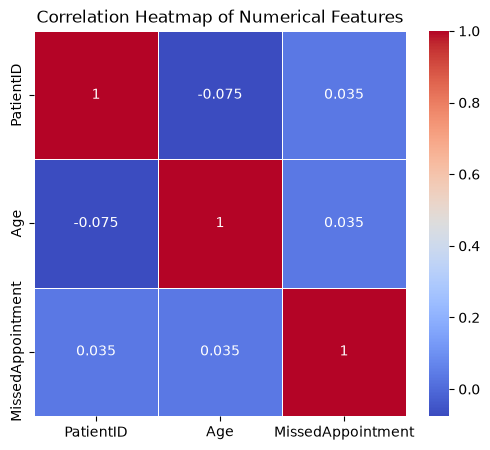

'\nplt.figure(figsize=(10, 8))\nsns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")\nplt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")\nplt.show()\n'

In [46]:
# Correlation matrix for numerical columns

# 1st Way
"""
numerical_columns = df.select_dtypes(include= [np.number]).columns
correlation_matrix = df[numerical_columns].corr
"""


# Second Way {Easy}
correlation_matrix = df.corr(numeric_only=True)


# Plot correlation heatmap
plt.figure(figsize=(6,5))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm',
linewidths=0.5)
plt.title('Correlation Heatmap of Numerical Features')
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()


"""
plt.figure(figsize=(10, 8))
sns.heatmap(data.corr(numeric_only=True), annot=True, cmap="coolwarm")
plt.savefig("correlation_heatmap.png", dpi=300, bbox_inches="tight")
plt.show()
"""

- Correlation analysis helps identify relationships between numerical features. In this dataset, all correlation values are close to zero, indicating that there is no strong linear relationship between Age and MissedAppointment. PatientID is merely an identifier and does not provide meaningful predictive information. Therefore, additional features should be explored to better understand appointment attendance patterns.

# Handling Missing Values

In [ ]:


# Check for missing values
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])


"""
df.isnull().sum() counts the number of missing values in each column. 
By applying the condition > 0, we filter and display only those columns that contain missing values,
making it easier to identify columns that require data cleaning.

"""

Series([], dtype: int64)


'\ndf.isnull().sum() counts the number of missing values in each column. \nBy applying the condition > 0, we filter and display only those columns that contain missing values,\nmaking it easier to identify columns that require data cleaning.\n\n'

In [48]:
"""
# Visualize missing values
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Value Heatmap')
plt.show()
"""

"\n# Visualize missing values\nplt.figure(figsize=(10, 6))\nsns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')\nplt.title('Missing Value Heatmap')\nplt.show()\n"

In [49]:
# # Methods of Handling missing values

# 1. Numeric columns: fill with median
numerical_columns = df.select_dtypes(include = [np.number]).columns

for cols in numerical_columns:
    df[col].fillna(df[cols].median(), inplace=True)

In [50]:
# 2. Categorical columns: fill with mode
categorical_columns = df.select_dtypes(include = [object]).columns

for col in categorical_columns:
    df[col].fillna(df[col].mode()[0], inplace=True)

"""mode()[0] is used to selct first mode because it resurn series od mode"""

'mode()[0] is used to selct first mode because it resurn series od mode'

In [51]:
# 3. Drop rows with any remaining missing values
df.dropna(inplace=True)

In [52]:
# 4. Drop columns with excessive missing values (threshold: 50%)
df = df.dropna(thresh=len(df) * 0.5, axis=1)

- dropna(thresh=n, axis=1) removes columns that do not have at least n non-missing values. In this example, columns with more than 50% missing data are removed because they may not provide reliable information for analysis or model training.

In [53]:
print("Data after handling missing values:")
print(df.info())

Data after handling missing values:
<class 'pandas.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 6 columns):
 #   Column             Non-Null Count  Dtype
---  ------             --------------  -----
 0   PatientID          100 non-null    int64
 1   Gender             100 non-null    str  
 2   Age                100 non-null    int64
 3   Diagnosis          100 non-null    str  
 4   AppointmentDate    100 non-null    str  
 5   MissedAppointment  100 non-null    int64
dtypes: int64(3), str(3)
memory usage: 4.8 KB
None


In [56]:
# Check for any remaining missing values
remaining_missing = df.isnull().sum().sum()
print(f"Remaining missing values: {remaining_missing}")

Remaining missing values: 0


In [58]:
# Display summary statistics after handling missing values
print("Summary Statistics After Handling Missing Values:")
print(df.describe())

Summary Statistics After Handling Missing Values:
        PatientID         Age  MissedAppointment
count  100.000000  100.000000         100.000000
mean    50.500000   52.370000           0.170000
std     29.011492   17.481682           0.377525
min      1.000000   18.000000           0.000000
25%     25.750000   40.000000           0.000000
50%     50.500000   52.000000           0.000000
75%     75.250000   67.000000           0.000000
max    100.000000   79.000000           1.000000


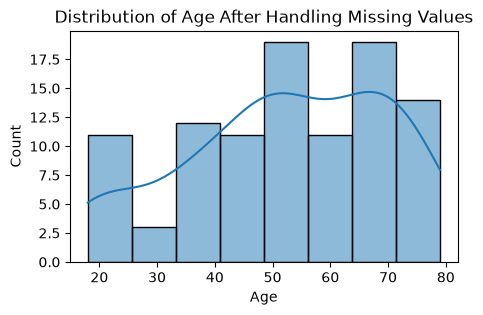

In [61]:
# Visualize the distribution of a key numeric variable (e.g., 'Age')
plt.figure(figsize=(5, 3))
sns.histplot(df['Age'], kde=True)
plt.title('Distribution of Age After Handling Missing Values')
plt.savefig("Distribution-Of-Age", dpi=300, bbox_inches="tight" )
plt.show()

# Handling Categorical Variables